# Advanced Data Science Lab

## Assignment 02

### Titanic Survival Analysis Dashboard

**Name :** Manthan Sankpal

**PRN :** 125M1H064

**Class :** SY MCA

**Course :** Advanced Data Science Lab

---

## Objective

To analyze the Titanic dataset using Streamlit and visualize passenger survival statistics based on gender, passenger class, and age.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,Pclass,Sex,Age,Fare,Survived
0,2,female,59.5,91.41,1
1,3,female,35.7,94.78,1
2,3,female,50.2,30.84,1
3,3,male,21.5,76.65,1
4,3,female,73.7,16.59,1


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [4]:
df.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Survived'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    200 non-null    int64  
 1   Sex       200 non-null    str    
 2   Age       200 non-null    float64
 3   Fare      200 non-null    float64
 4   Survived  200 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 8.9 KB


In [6]:
df.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
dtype: int64

In [7]:
df = df.dropna()

df.head()

,Pclass,Sex,Age,Fare,Survived
0,2,female,59.5,91.41,1
1,3,female,35.7,94.78,1
2,3,female,50.2,30.84,1
3,3,male,21.5,76.65,1
4,3,female,73.7,16.59,1


In [8]:
df["SurvivalStatus"] = df["Survived"].replace({
    0: "Not Survived",
    1: "Survived"
})

df.head()

,Pclass,Sex,Age,Fare,Survived,SurvivalStatus
0,2,female,59.5,91.41,1,Survived
1,3,female,35.7,94.78,1,Survived
2,3,female,50.2,30.84,1,Survived
3,3,male,21.5,76.65,1,Survived
4,3,female,73.7,16.59,1,Survived


In [9]:
df["PassengerClass"] = df["Pclass"].replace({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

df.head()

,Pclass,Sex,Age,Fare,Survived,SurvivalStatus,PassengerClass
0,2,female,59.5,91.41,1,Survived,Second Class
1,3,female,35.7,94.78,1,Survived,Third Class
2,3,female,50.2,30.84,1,Survived,Third Class
3,3,male,21.5,76.65,1,Survived,Third Class
4,3,female,73.7,16.59,1,Survived,Third Class


In [10]:
gender_survival = (
    df.groupby("Sex")["Survived"]
      .mean()
      * 100
)

gender_survival = gender_survival.round(2)

gender_survival

Sex
female    51.38
male      53.85
Name: Survived, dtype: float64

In [11]:
class_survival = (
    df.groupby("PassengerClass")["Survived"]
      .mean()
      * 100
)

class_survival = class_survival.round(2)

class_survival

PassengerClass
First Class     56.94
Second Class    50.00
Third Class     50.00
Name: Survived, dtype: float64

In [12]:
average_age = (
    df.groupby("SurvivalStatus")["Age"]
      .mean()
)

average_age

SurvivalStatus
Not Survived    43.745263
Survived        41.099048
Name: Age, dtype: float64

<Figure size 600x500 with 0 Axes>

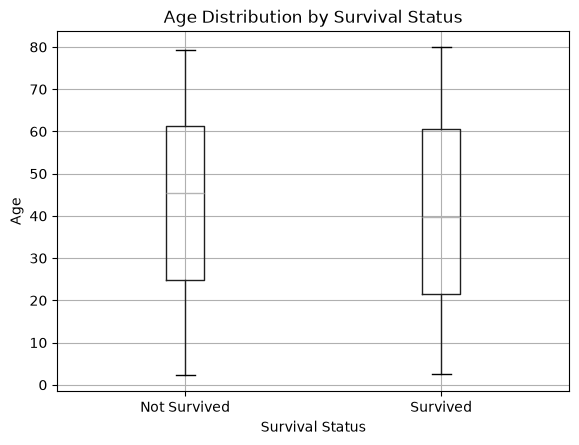

In [13]:
plt.figure(figsize=(6,5))

df.boxplot(
    column="Age",
    by="SurvivalStatus"
)

plt.title("Age Distribution by Survival Status")
plt.suptitle("")

plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.show()